# Adult Census Income Dataset

Задача: предсказать, зарабатывает человек более 50к долларов в год или нет (label: 0 - <=50K, 1 - >50K)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загружаем данные
df = pd.read_csv('adult_data_train.csv')

print(f"Размер датасета: {df.shape}")
print(f"\nПервые строки:")
df.head(10)

Размер датасета: (26048, 15)

Первые строки:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,label
0,32,Private,37210,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,1
1,43,Private,101950,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,45,United-States,0
2,20,?,122244,HS-grad,9,Never-married,?,Not-in-family,White,Female,0,0,28,United-States,0
3,40,Local-gov,24763,Some-college,10,Divorced,Transport-moving,Unmarried,White,Male,6849,0,40,United-States,0
4,24,Private,113936,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,0
5,51,Private,237630,HS-grad,9,Married-civ-spouse,Tech-support,Husband,White,Male,7298,0,50,United-States,1
6,44,Private,310255,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,60,United-States,1
7,53,Private,121441,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,55,United-States,0
8,44,Self-emp-inc,191712,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,2415,55,United-States,1
9,28,?,149646,Some-college,10,Divorced,?,Own-child,White,Female,0,0,20,?,0


In [3]:
# Информация о датасете
print("Информация о столбцах:")
print(df.info())
print("\n" + "="*80)
print("\nСтатистика по числовым признакам:")
df.describe()

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26048 entries, 0 to 26047
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             26048 non-null  int64 
 1   workclass       26048 non-null  object
 2   fnlwgt          26048 non-null  int64 
 3   education       26048 non-null  object
 4   education-num   26048 non-null  int64 
 5   marital-status  26048 non-null  object
 6   occupation      26048 non-null  object
 7   relationship    26048 non-null  object
 8   race            26048 non-null  object
 9   sex             26048 non-null  object
 10  capital-gain    26048 non-null  int64 
 11  capital-loss    26048 non-null  int64 
 12  hours-per-week  26048 non-null  int64 
 13  native-country  26048 non-null  object
 14  label           26048 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.0+ MB
None


Статистика по числовым признакам:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,label
count,26048.000000,2.604800e+04,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000
mean,38.589373,1.900018e+05,10.079661,1060.682740,88.026259,40.480728,0.240825
std,13.641016,1.055103e+05,2.583186,7299.149781,404.983608,12.417613,0.427592
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.181942e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.785535e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.374578e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [4]:
# Распределение целевой переменной
print("Распределение классов:")
print(df['label'].value_counts())
print(f"\nДоля класса 1 (>50K): {df['label'].mean():.2%}")
print(f"Доля класса 0 (<=50K): {(1 - df['label'].mean()):.2%}")

Распределение классов:
label
0    19775
1     6273
Name: count, dtype: int64

Доля класса 1 (>50K): 24.08%
Доля класса 0 (<=50K): 75.92%


In [5]:
# Удаляем признаки education и marital-status
df = df.drop(columns=['education', 'marital-status'])

print("Оставшиеся столбцы:")
print(df.columns.tolist())
print(f"\nОбщее количество признаков (без label): {len(df.columns) - 1}")

Оставшиеся столбцы:
['age', 'workclass', 'fnlwgt', 'education-num', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'label']

Общее количество признаков (без label): 12


In [6]:
# Определяем типы признаков
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Убираем label из подсчета
if 'label' in numerical_features:
    numerical_features.remove('label')

print("Числовые признаки:")
print(numerical_features)
print(f"Количество: {len(numerical_features)}")

print("\nНечисловые (категориальные) признаки:")
print(categorical_features)
print(f"Количество: {len(categorical_features)}")

print(f"\n{'='*60}")
print(f"Итого числовых признаков: {len(numerical_features)}")
print(f"Итого нечисловых признаков: {len(categorical_features)}")
print(f"Всего признаков (без label): {len(numerical_features) + len(categorical_features)}")

Числовые признаки:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Количество: 6

Нечисловые (категориальные) признаки:
['workclass', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Количество: 6

Итого числовых признаков: 6
Итого нечисловых признаков: 6
Всего признаков (без label): 12


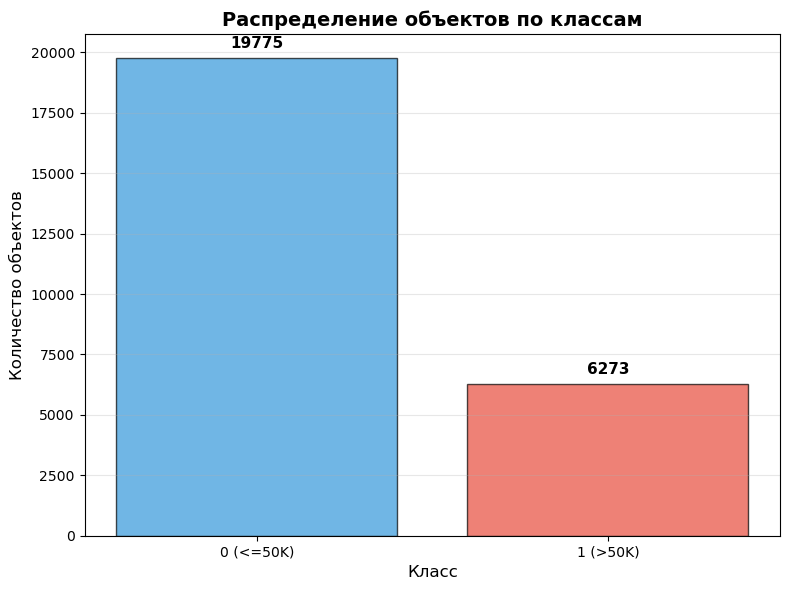

Всего объектов: 26048
Объектов класса 0 (<=50K): 19775
Объектов класса 1 (>50K): 6273
Доля объектов класса 0: 0.759175
Доля объектов класса 0: 75.92%


In [7]:
# Построение гистограммы распределения по классам
plt.figure(figsize=(8, 6))
class_counts = df['label'].value_counts().sort_index()
plt.bar(class_counts.index, class_counts.values, color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Количество объектов', fontsize=12)
plt.title('Распределение объектов по классам', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['0 (<=50K)', '1 (>50K)'])
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 300, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Вычисляем долю класса 0
total_objects = len(df)
class_0_count = (df['label'] == 0).sum()
class_0_ratio = class_0_count / total_objects

print(f"{'='*60}")
print(f"Всего объектов: {total_objects}")
print(f"Объектов класса 0 (<=50K): {class_0_count}")
print(f"Объектов класса 1 (>50K): {(df['label'] == 1).sum()}")
print(f"{'='*60}")
print(f"Доля объектов класса 0: {class_0_ratio:.6f}")
print(f"Доля объектов класса 0: {class_0_ratio * 100:.2f}%")

In [8]:
from sklearn.model_selection import train_test_split

# Отбираем только числовые признаки
numerical_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
X = df[numerical_features]
y = df['label']

print("Числовые признаки для обучения:")
print(X.columns.tolist())
print(f"\nРазмерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

# Разбиваем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=9, 
    stratify=y
)

print(f"\n{'='*60}")
print("Результаты разбиения:")
print(f"{'='*60}")
print(f"Обучающая выборка: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Тестовая выборка:  X_test {X_test.shape}, y_test {y_test.shape}")

print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts().sort_index())
print(f"Доля класса 1: {y_train.mean():.4f}")

print(f"\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts().sort_index())
print(f"Доля класса 1: {y_test.mean():.4f}")

Числовые признаки для обучения:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Размерность X: (26048, 6)
Размерность y: (26048,)

Результаты разбиения:
Обучающая выборка: X_train (20838, 6), y_train (20838,)
Тестовая выборка:  X_test (5210, 6), y_test (5210,)

Распределение классов в обучающей выборке:
label
0    15820
1     5018
Name: count, dtype: int64
Доля класса 1: 0.2408

Распределение классов в тестовой выборке:
label
0    3955
1    1255
Name: count, dtype: int64
Доля класса 1: 0.2409


In [9]:
# Вычисляем выборочное среднее колонки fnlwgt в тренировочном наборе
fnlwgt_mean = X_train['fnlwgt'].mean()

print(f"Выборочное среднее колонки fnlwgt (тренировочная выборка):")
print(f"{fnlwgt_mean}")
print(f"\nОкругленное значение: {fnlwgt_mean:.2f}")

# Дополнительная статистика
print(f"\n{'='*60}")
print("Дополнительная статистика fnlwgt (тренировочная выборка):")
print(f"{'='*60}")
print(f"Среднее:        {X_train['fnlwgt'].mean():.2f}")
print(f"Медиана:        {X_train['fnlwgt'].median():.2f}")
print(f"Стд. отклонение: {X_train['fnlwgt'].std():.2f}")
print(f"Минимум:        {X_train['fnlwgt'].min()}")
print(f"Максимум:       {X_train['fnlwgt'].max()}")

Выборочное среднее колонки fnlwgt (тренировочная выборка):
190095.05134849795

Округленное значение: 190095.05

Дополнительная статистика fnlwgt (тренировочная выборка):
Среднее:        190095.05
Медиана:        178983.00
Стд. отклонение: 105225.49
Минимум:        14878
Максимум:       1484705


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, accuracy_score

# Обучаем модель KNeighborsClassifier с параметрами по умолчанию
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

print("Модель KNeighborsClassifier обучена")
print(f"Параметры модели: {knn.get_params()}")

# Делаем предсказания на тестовой выборке
y_pred = knn.predict(X_test)

# Вычисляем метрики
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*60}")
print("Результаты на тестовой выборке:")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.6f}")
print(f"F1-score: {f1:.6f}")

print(f"\n{classification_report(y_test, y_pred, target_names=['Class 0 (<=50K)', 'Class 1 (>50K)'])}")

Модель KNeighborsClassifier обучена
Параметры модели: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}

Результаты на тестовой выборке:
Accuracy: 0.771209
F1-score: 0.391216

                 precision    recall  f1-score   support

Class 0 (<=50K)       0.81      0.92      0.86      3955
 Class 1 (>50K)       0.54      0.31      0.39      1255

       accuracy                           0.77      5210
      macro avg       0.68      0.61      0.63      5210
   weighted avg       0.74      0.77      0.75      5210



In [11]:
from sklearn.preprocessing import MinMaxScaler

# Обучаем MinMaxScaler на тренировочных данных
scaler = MinMaxScaler()
scaler.fit(X_train)

# Применяем преобразование к тренировочным и тестовым данным
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame для удобства
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("MinMaxScaler обучен и применен к данным")
print(f"\nРазмерность масштабированных данных:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

# Вычисляем выборочное среднее колонки fnlwgt после масштабирования
fnlwgt_mean_scaled = X_train_scaled['fnlwgt'].mean()

print(f"\n{'='*60}")
print(f"Выборочное среднее колонки fnlwgt (масштабированная тренировочная выборка):")
print(f"{fnlwgt_mean_scaled}")
print(f"\n{'='*60}")

# Показываем диапазоны значений после масштабирования
print("\nДиапазоны значений после MinMaxScaler (тренировочная выборка):")
for col in X_train_scaled.columns:
    print(f"{col:20s}: [{X_train_scaled[col].min():.6f}, {X_train_scaled[col].max():.6f}]")

MinMaxScaler обучен и применен к данным

Размерность масштабированных данных:
X_train_scaled: (20838, 6)
X_test_scaled: (5210, 6)

Выборочное среднее колонки fnlwgt (масштабированная тренировочная выборка):
0.11920930242028344


Диапазоны значений после MinMaxScaler (тренировочная выборка):
age                 : [0.000000, 1.000000]
fnlwgt              : [0.000000, 1.000000]
education-num       : [0.000000, 1.000000]
capital-gain        : [0.000000, 1.000000]
capital-loss        : [0.000000, 1.000000]
hours-per-week      : [0.000000, 1.000000]


In [12]:
# Обучаем модель KNeighborsClassifier на масштабированных данных
knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)

print("Модель KNeighborsClassifier обучена на масштабированных данных")
print(f"Параметры модели: {knn_scaled.get_params()}")

# Делаем предсказания на масштабированной тестовой выборке
y_pred_scaled = knn_scaled.predict(X_test_scaled)

# Вычисляем метрики
f1_scaled = f1_score(y_test, y_pred_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"\n{'='*60}")
print("Результаты на тестовой выборке (масштабированные данные):")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_scaled:.6f}")
print(f"F1-score: {f1_scaled:.6f}")

print(f"\n{classification_report(y_test, y_pred_scaled, target_names=['Class 0 (<=50K)', 'Class 1 (>50K)'])}")

# Сравнение с предыдущей моделью
print(f"{'='*60}")
print("Сравнение с моделью без масштабирования:")
print(f"{'='*60}")
print(f"F1-score без масштабирования: {f1:.6f}")
print(f"F1-score с масштабированием:  {f1_scaled:.6f}")
print(f"Улучшение: {(f1_scaled - f1):.6f} ({((f1_scaled - f1) / f1 * 100):.2f}%)")

Модель KNeighborsClassifier обучена на масштабированных данных
Параметры модели: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}

Результаты на тестовой выборке (масштабированные данные):
Accuracy: 0.799616
F1-score: 0.519779

                 precision    recall  f1-score   support

Class 0 (<=50K)       0.84      0.91      0.87      3955
 Class 1 (>50K)       0.61      0.45      0.52      1255

       accuracy                           0.80      5210
      macro avg       0.73      0.68      0.70      5210
   weighted avg       0.79      0.80      0.79      5210

Сравнение с моделью без масштабирования:
F1-score без масштабирования: 0.391216
F1-score с масштабированием:  0.519779
Улучшение: 0.128564 (32.86%)


In [13]:
# Возвращаемся к исходному датасету без education и marital-status
df_full = pd.read_csv('adult_data_train.csv')
df_full = df_full.drop(columns=['education', 'marital-status'])

print("Датасет загружен заново")
print(f"Размерность: {df_full.shape}")

# Определяем нечисловые признаки
categorical_features = ['workclass', 'occupation', 'relationship', 'race', 'sex', 'native-country']

print(f"\nНечисловые признаки для визуализации:")
for feat in categorical_features:
    print(f"  - {feat}: {df_full[feat].nunique()} уникальных значений")

Датасет загружен заново
Размерность: (26048, 13)

Нечисловые признаки для визуализации:
  - workclass: 9 уникальных значений
  - occupation: 15 уникальных значений
  - relationship: 6 уникальных значений
  - race: 5 уникальных значений
  - sex: 2 уникальных значений
  - native-country: 42 уникальных значений


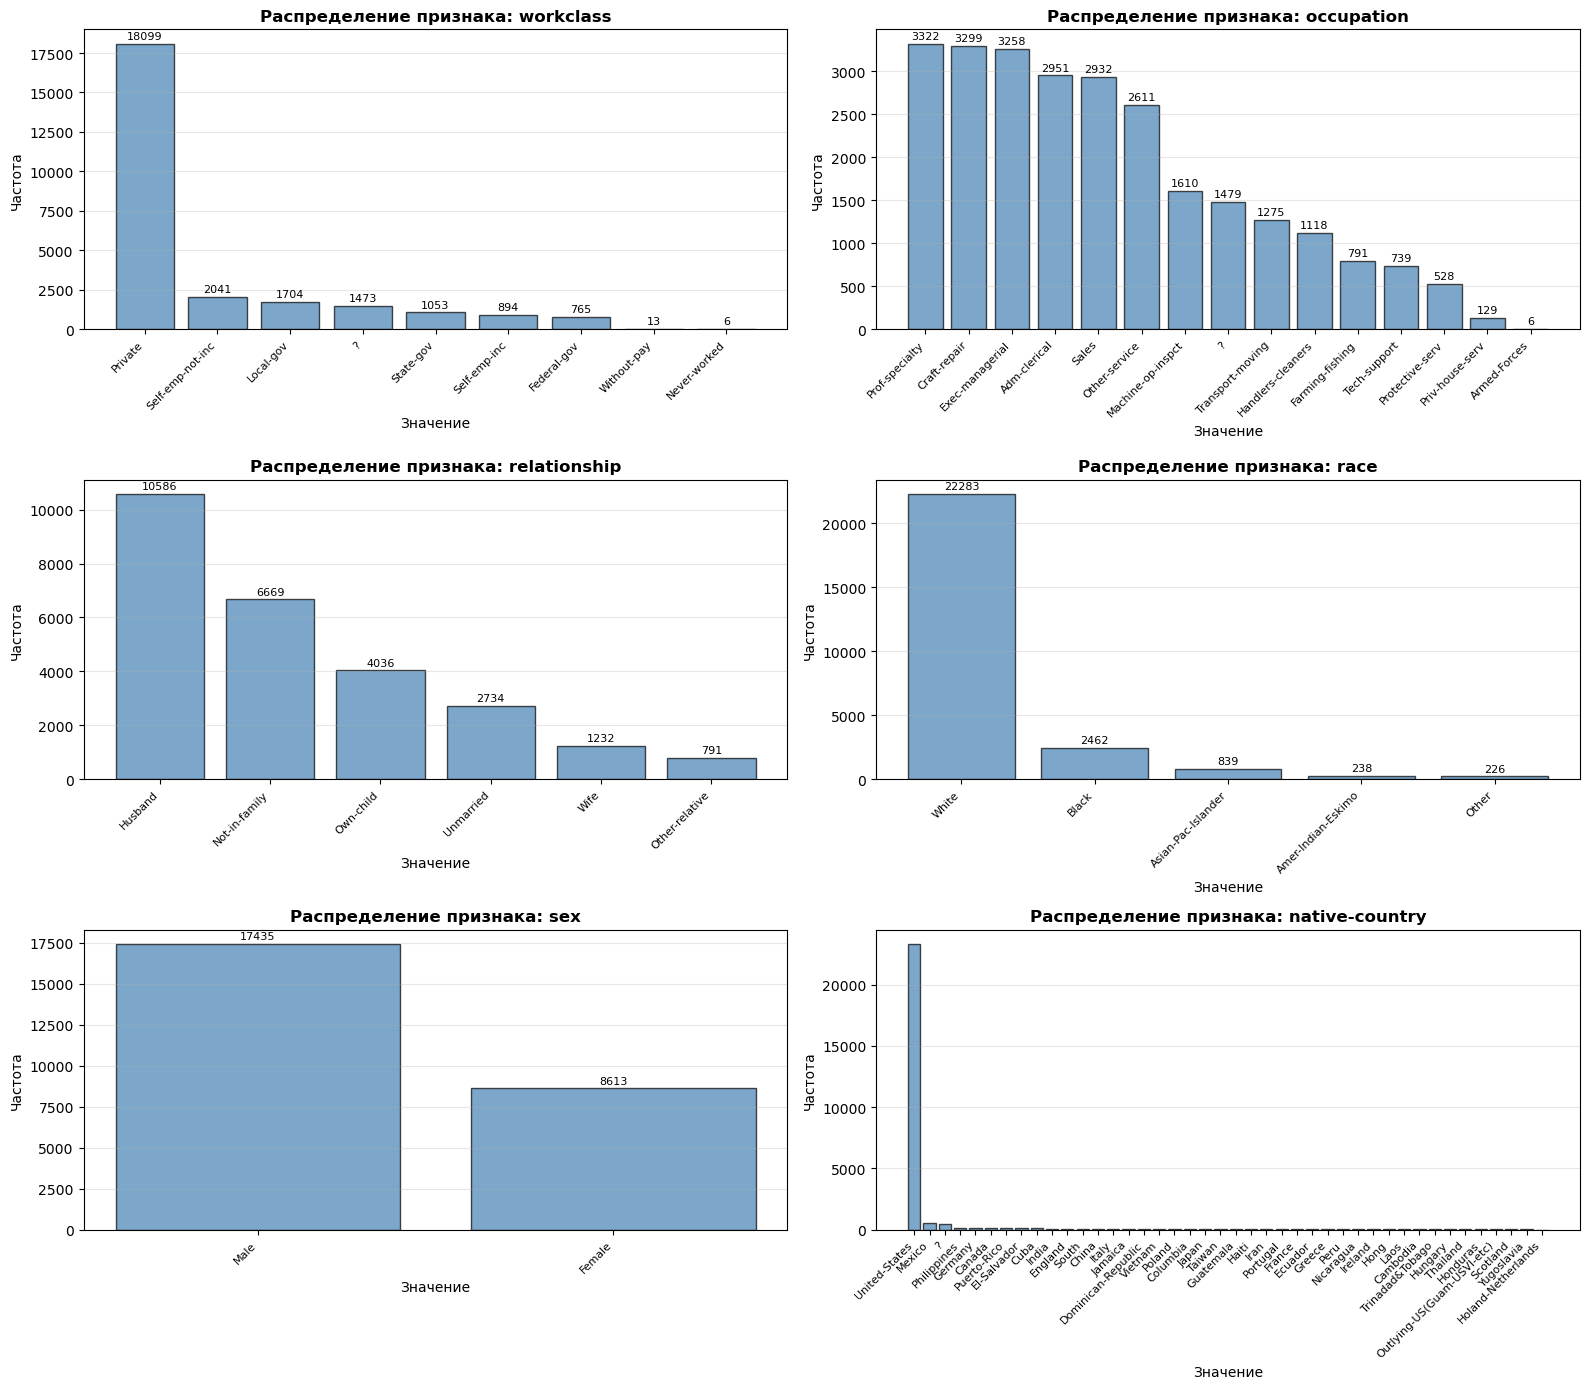

Статистика по категориальным признакам:

workclass:
workclass
Private             18099
Self-emp-not-inc     2041
Local-gov            1704
?                    1473
State-gov            1053
Self-emp-inc          894
Federal-gov           765
Without-pay            13
Never-worked            6
Name: count, dtype: int64

occupation:
occupation
Prof-specialty       3322
Craft-repair         3299
Exec-managerial      3258
Adm-clerical         2951
Sales                2932
Other-service        2611
Machine-op-inspct    1610
?                    1479
Transport-moving     1275
Handlers-cleaners    1118
Name: count, dtype: int64

relationship:
relationship
Husband           10586
Not-in-family      6669
Own-child          4036
Unmarried          2734
Wife               1232
Other-relative      791
Name: count, dtype: int64

race:
race
White                 22283
Black                  2462
Asian-Pac-Islander      839
Amer-Indian-Eskimo      238
Other                   226
Name: count, dtype

In [14]:
# Строим гистограммы для каждого нечислового признака
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    ax = axes[idx]
    
    # Подсчитываем частоту значений
    value_counts = df_full[feature].value_counts()
    
    # Строим столбчатую диаграмму
    ax.bar(range(len(value_counts)), value_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Значение', fontsize=10)
    ax.set_ylabel('Частота', fontsize=10)
    ax.set_title(f'Распределение признака: {feature}', fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы (только если значений не слишком много)
    if len(value_counts) <= 15:
        for i, v in enumerate(value_counts.values):
            ax.text(i, v + max(value_counts.values) * 0.01, str(v), 
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Выводим статистику
print("Статистика по категориальным признакам:")
print("="*60)
for feature in categorical_features:
    print(f"\n{feature}:")
    print(df_full[feature].value_counts().head(10))

In [15]:
# Проверяем пропущенные значения (обозначенные как "?")
# В данном датасете пропущенные значения представлены как "?"

print("Проверка пропущенных значений в датасете")
print(f"Всего строк: {len(df_full)}")
print(f"\n{'='*60}")

# Считаем количество "?" в каждой колонке
print("Количество '?' по колонкам:")
for col in df_full.columns:
    if df_full[col].dtype == 'object':  # Только для нечисловых колонок
        missing_count = (df_full[col] == '?').sum()
        if missing_count > 0:
            print(f"  {col:20s}: {missing_count}")

# Находим строки, в которых есть хотя бы одно пропущенное значение "?"
rows_with_missing = df_full.apply(lambda row: (row == '?').any(), axis=1)
num_rows_with_missing = rows_with_missing.sum()

print(f"\n{'='*60}")
print(f"Количество строк с хотя бы одним пропущенным значением ('?'): {num_rows_with_missing}")
print(f"Доля таких строк: {num_rows_with_missing / len(df_full) * 100:.2f}%")

# Показываем примеры строк с пропущенными значениями
print(f"\n{'='*60}")
print("Примеры строк с пропущенными значениями:")
print(df_full[rows_with_missing].head(5))

Проверка пропущенных значений в датасете
Всего строк: 26048

Количество '?' по колонкам:
  workclass           : 1473
  occupation          : 1479
  native-country      : 458



Количество строк с хотя бы одним пропущенным значением ('?'): 1914
Доля таких строк: 7.35%

Примеры строк с пропущенными значениями:
    age workclass  fnlwgt  education-num occupation   relationship   race  \
2    20         ?  122244              9          ?  Not-in-family  White   
9    28         ?  149646             10          ?      Own-child  White   
14   60         ?  251572              9          ?  Not-in-family  White   
15   34         ?  317219             10          ?           Wife  White   
40   36         ?   94954             11          ?  Not-in-family  White   

       sex  capital-gain  capital-loss  hours-per-week native-country  label  
2   Female             0             0              28  United-States      0  
9   Female             0             0              20              ?      0  
14    Male             0             0              35         Poland      0  
15  Female             0             0              20  United-States      1  
40  Fema

In [16]:
# Удаляем строки с пропущенными значениями "?"
rows_with_missing = df_full.apply(lambda row: (row == '?').any(), axis=1)
df_clean = df_full[~rows_with_missing].copy()

print(f"Исходное количество строк: {len(df_full)}")
print(f"Удалено строк с пропусками: {len(df_full) - len(df_clean)}")
print(f"Осталось строк: {len(df_clean)}")

# Разделяем на признаки и целевую переменную
X_full = df_clean.drop(columns=['label'])
y_full = df_clean['label']

print(f"\n{'='*60}")
print(f"Признаков до one-hot кодирования: {X_full.shape[1]}")
print(f"Числовые признаки: {X_full.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"Категориальные признаки: {X_full.select_dtypes(include=['object']).shape[1]}")

Исходное количество строк: 26048
Удалено строк с пропусками: 1914
Осталось строк: 24134

Признаков до one-hot кодирования: 12
Числовые признаки: 6
Категориальные признаки: 6


In [17]:
# Применяем one-hot кодирование с drop_first=True
X_encoded = pd.get_dummies(X_full, drop_first=True)

print(f"{'='*60}")
print("Результаты one-hot кодирования:")
print(f"{'='*60}")
print(f"Размерность закодированного набора данных: {X_encoded.shape}")
print(f"Общее число полученных признаков: {X_encoded.shape[1]}")

print(f"\n{'='*60}")
print("Список всех признаков после кодирования:")
print(f"{'='*60}")
for i, col in enumerate(X_encoded.columns, 1):
    print(f"{i:3d}. {col}")

print(f"\n{'='*60}")
print(f"Итого признаков: {X_encoded.shape[1]}")

Результаты one-hot кодирования:
Размерность закодированного набора данных: (24134, 75)
Общее число полученных признаков: 75

Список всех признаков после кодирования:
  1. age
  2. fnlwgt
  3. education-num
  4. capital-gain
  5. capital-loss
  6. hours-per-week
  7. workclass_Local-gov
  8. workclass_Private
  9. workclass_Self-emp-inc
 10. workclass_Self-emp-not-inc
 11. workclass_State-gov
 12. workclass_Without-pay
 13. occupation_Armed-Forces
 14. occupation_Craft-repair
 15. occupation_Exec-managerial
 16. occupation_Farming-fishing
 17. occupation_Handlers-cleaners
 18. occupation_Machine-op-inspct
 19. occupation_Other-service
 20. occupation_Priv-house-serv
 21. occupation_Prof-specialty
 22. occupation_Protective-serv
 23. occupation_Sales
 24. occupation_Tech-support
 25. occupation_Transport-moving
 26. relationship_Not-in-family
 27. relationship_Other-relative
 28. relationship_Own-child
 29. relationship_Unmarried
 30. relationship_Wife
 31. race_Asian-Pac-Islander
 32. r

In [18]:
# Разбиваем данные на train/test с параметрами как в базовой модели
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_encoded, y_full,
    test_size=0.2,
    random_state=9,
    stratify=y_full
)

print("Разбиение данных:")
print(f"X_train: {X_train_full.shape}, y_train: {y_train_full.shape}")
print(f"X_test:  {X_test_full.shape}, y_test:  {y_test_full.shape}")

print(f"\nРаспределение классов в обучающей выборке:")
print(y_train_full.value_counts().sort_index())
print(f"Доля класса 1: {y_train_full.mean():.4f}")

print(f"\nРаспределение классов в тестовой выборке:")
print(y_test_full.value_counts().sort_index())
print(f"Доля класса 1: {y_test_full.mean():.4f}")

Разбиение данных:
X_train: (19307, 75), y_train: (19307,)
X_test:  (4827, 75), y_test:  (4827,)

Распределение классов в обучающей выборке:
label
0    14501
1     4806
Name: count, dtype: int64
Доля класса 1: 0.2489

Распределение классов в тестовой выборке:
label
0    3626
1    1201
Name: count, dtype: int64
Доля класса 1: 0.2488


In [19]:
# Применяем MinMaxScaler
scaler_full = MinMaxScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

print("MinMaxScaler применен")
print(f"X_train_scaled: {X_train_full_scaled.shape}")
print(f"X_test_scaled:  {X_test_full_scaled.shape}")

MinMaxScaler применен
X_train_scaled: (19307, 75)
X_test_scaled:  (4827, 75)


In [20]:
# Обучаем KNeighborsClassifier с параметрами по умолчанию
knn_full = KNeighborsClassifier()
knn_full.fit(X_train_full_scaled, y_train_full)

print("Модель KNeighborsClassifier обучена на полном наборе признаков")
print(f"Параметры модели: {knn_full.get_params()}")

# Делаем предсказания на тестовой выборке
y_pred_full = knn_full.predict(X_test_full_scaled)

# Вычисляем метрики
f1_full = f1_score(y_test_full, y_pred_full)
accuracy_full = accuracy_score(y_test_full, y_pred_full)

print(f"\n{'='*60}")
print("Результаты на тестовой выборке (полный набор признаков):")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_full:.6f}")
print(f"F1-score: {f1_full:.6f}")

print(f"\n{classification_report(y_test_full, y_pred_full, target_names=['Class 0 (<=50K)', 'Class 1 (>50K)'])}")

Модель KNeighborsClassifier обучена на полном наборе признаков
Параметры модели: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}

Результаты на тестовой выборке (полный набор признаков):
Accuracy: 0.820593
F1-score: 0.616135

                 precision    recall  f1-score   support

Class 0 (<=50K)       0.87      0.90      0.88      3626
 Class 1 (>50K)       0.66      0.58      0.62      1201

       accuracy                           0.82      4827
      macro avg       0.76      0.74      0.75      4827
   weighted avg       0.81      0.82      0.82      4827



In [21]:
# Сравнение всех моделей
print("="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ:")
print("="*60)
print(f"\n1. KNN без масштабирования (только числовые признаки):")
print(f"   F1-score: {f1:.6f}")
print(f"   Accuracy: {accuracy:.6f}")

print(f"\n2. KNN с масштабированием (только числовые признаки):")
print(f"   F1-score: {f1_scaled:.6f}")
print(f"   Accuracy: {accuracy_scaled:.6f}")

print(f"\n3. KNN с масштабированием (все признаки + one-hot):")
print(f"   F1-score: {f1_full:.6f}")
print(f"   Accuracy: {accuracy_full:.6f}")

print(f"\n{'='*60}")
print(f"Улучшение модели 3 по сравнению с моделью 2:")
print(f"  F1-score: +{(f1_full - f1_scaled):.6f} ({((f1_full - f1_scaled) / f1_scaled * 100):.2f}%)")
print(f"  Accuracy: +{(accuracy_full - accuracy_scaled):.6f} ({((accuracy_full - accuracy_scaled) / accuracy_scaled * 100):.2f}%)")

СРАВНЕНИЕ МОДЕЛЕЙ:

1. KNN без масштабирования (только числовые признаки):
   F1-score: 0.391216
   Accuracy: 0.771209

2. KNN с масштабированием (только числовые признаки):
   F1-score: 0.519779
   Accuracy: 0.799616

3. KNN с масштабированием (все признаки + one-hot):
   F1-score: 0.616135
   Accuracy: 0.820593

Улучшение модели 3 по сравнению с моделью 2:
  F1-score: +0.096356 (18.54%)
  Accuracy: +0.020976 (2.62%)


In [22]:
# Загружаем исходный датасет заново
df_imputed = pd.read_csv('adult_data_train.csv')
df_imputed = df_imputed.drop(columns=['education', 'marital-status'])

print(f"Исходный датасет загружен: {df_imputed.shape}")
print(f"\n{'='*60}")
print("Пропущенные значения ('?') до заполнения:")
for col in df_imputed.columns:
    if df_imputed[col].dtype == 'object':
        missing_count = (df_imputed[col] == '?').sum()
        if missing_count > 0:
            print(f"  {col:20s}: {missing_count}")

Исходный датасет загружен: (26048, 13)

Пропущенные значения ('?') до заполнения:
  workclass           : 1473
  occupation          : 1479
  native-country      : 458


In [23]:
# Заполняем пропуски самым часто встречающимся значением (модой)
categorical_cols = ['workclass', 'occupation', 'native-country']

for col in categorical_cols:
    # Находим самое частое значение (исключая '?')
    mode_value = df_imputed[df_imputed[col] != '?'][col].mode()[0]
    
    # Заполняем '?' на моду
    missing_count_before = (df_imputed[col] == '?').sum()
    df_imputed[col] = df_imputed[col].replace('?', mode_value)
    missing_count_after = (df_imputed[col] == '?').sum()
    
    print(f"{col:20s}: заменено {missing_count_before} пропусков на '{mode_value}'")

print(f"\n{'='*60}")
print("Проверка пропусков после заполнения:")
for col in df_imputed.columns:
    if df_imputed[col].dtype == 'object':
        missing_count = (df_imputed[col] == '?').sum()
        print(f"  {col:20s}: {missing_count}")

print(f"\nВсего строк: {len(df_imputed)}")
print(f"Строк с пропусками: {df_imputed.apply(lambda row: (row == '?').any(), axis=1).sum()}")

workclass           : заменено 1473 пропусков на 'Private'
occupation          : заменено 1479 пропусков на 'Prof-specialty'
native-country      : заменено 458 пропусков на 'United-States'

Проверка пропусков после заполнения:
  workclass           : 0
  occupation          : 0
  relationship        : 0
  race                : 0
  sex                 : 0
  native-country      : 0

Всего строк: 26048


Строк с пропусками: 0


In [24]:
# Разделяем на признаки и целевую переменную
X_imputed = df_imputed.drop(columns=['label'])
y_imputed = df_imputed['label']

# Применяем one-hot кодирование
X_imputed_encoded = pd.get_dummies(X_imputed, drop_first=True)

print(f"{'='*60}")
print("One-hot кодирование:")
print(f"{'='*60}")
print(f"Размерность данных: {X_imputed_encoded.shape}")
print(f"Количество признаков: {X_imputed_encoded.shape[1]}")
print(f"Количество объектов: {X_imputed_encoded.shape[0]}")

One-hot кодирование:
Размерность данных: (26048, 76)
Количество признаков: 76
Количество объектов: 26048


In [25]:
# Split: разбиваем на train/test
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imputed_encoded, y_imputed,
    test_size=0.2,
    random_state=9,
    stratify=y_imputed
)

print("Разбиение данных:")
print(f"X_train: {X_train_imp.shape}, y_train: {y_train_imp.shape}")
print(f"X_test:  {X_test_imp.shape}, y_test:  {y_test_imp.shape}")

# Scaling: применяем MinMaxScaler
scaler_imp = MinMaxScaler()
X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

print(f"\nМасштабирование применено")

# Обучение модели
knn_imp = KNeighborsClassifier()
knn_imp.fit(X_train_imp_scaled, y_train_imp)

print(f"\nМодель KNeighborsClassifier обучена")

# Предсказание и оценка
y_pred_imp = knn_imp.predict(X_test_imp_scaled)

f1_imp = f1_score(y_test_imp, y_pred_imp)
accuracy_imp = accuracy_score(y_test_imp, y_pred_imp)

print(f"\n{'='*60}")
print("Результаты на тестовой выборке (с заполнением пропусков):")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_imp:.6f}")
print(f"F1-score: {f1_imp:.6f}")

print(f"\n{classification_report(y_test_imp, y_pred_imp, target_names=['Class 0 (<=50K)', 'Class 1 (>50K)'])}")

Разбиение данных:
X_train: (20838, 76), y_train: (20838,)
X_test:  (5210, 76), y_test:  (5210,)

Масштабирование применено

Модель KNeighborsClassifier обучена

Результаты на тестовой выборке (с заполнением пропусков):
Accuracy: 0.818042
F1-score: 0.591379

                 precision    recall  f1-score   support

Class 0 (<=50K)       0.86      0.90      0.88      3955
 Class 1 (>50K)       0.64      0.55      0.59      1255

       accuracy                           0.82      5210
      macro avg       0.75      0.73      0.74      5210
   weighted avg       0.81      0.82      0.81      5210



In [26]:
# Финальное сравнение всех моделей
print("="*70)
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ:")
print("="*70)

print(f"\n1. KNN без масштабирования (только числовые признаки):")
print(f"   F1-score: {f1:.6f}")
print(f"   Accuracy: {accuracy:.6f}")

print(f"\n2. KNN с масштабированием (только числовые признаки):")
print(f"   F1-score: {f1_scaled:.6f}")
print(f"   Accuracy: {accuracy_scaled:.6f}")

print(f"\n3. KNN + one-hot (удаление строк с пропусками, 24134 строки):")
print(f"   F1-score: {f1_full:.6f}")
print(f"   Accuracy: {accuracy_full:.6f}")

print(f"\n4. KNN + one-hot (заполнение пропусков модой, 26048 строк):")
print(f"   F1-score: {f1_imp:.6f}")
print(f"   Accuracy: {accuracy_imp:.6f}")

print(f"\n{'='*70}")
print("Выводы:")
print(f"  - Лучший F1-score: модель 3 (удаление пропусков) - {f1_full:.6f}")
print(f"  - Модель с заполнением пропусков: F1 = {f1_imp:.6f}")
print(f"  - Разница: {(f1_full - f1_imp):.6f} ({((f1_full - f1_imp) / f1_full * 100):.2f}%)")

ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ:

1. KNN без масштабирования (только числовые признаки):
   F1-score: 0.391216
   Accuracy: 0.771209

2. KNN с масштабированием (только числовые признаки):
   F1-score: 0.519779
   Accuracy: 0.799616

3. KNN + one-hot (удаление строк с пропусками, 24134 строки):
   F1-score: 0.616135
   Accuracy: 0.820593

4. KNN + one-hot (заполнение пропусков модой, 26048 строк):
   F1-score: 0.591379
   Accuracy: 0.818042

Выводы:
  - Лучший F1-score: модель 3 (удаление пропусков) - 0.616135
  - Модель с заполнением пропусков: F1 = 0.591379
  - Разница: 0.024755 (4.02%)
